In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv("loan_approval_dataset.csv")

In [4]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [5]:
x=df.drop(columns=["Loan_Approved"])
y=df['Loan_Approved']

In [6]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [7]:
x.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [8]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

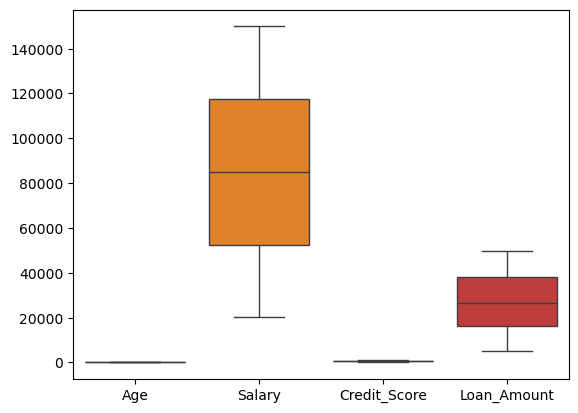

In [9]:
sns.boxplot(data=x[num_cols])

In [10]:
xtrain[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

Preprocessing Technique

 - Scaling
 - Encoding

why scaling ? 
 Features(numerical) columns values are different range(scale).so we can use scaling to equal importance for all the feature cols 

 why encoding ?
 Algorithmes can understand only numbers not strings

 which Scaling and encoding techniques we can use for this ?
 Scaling - min maxscaler,sytandardScalar
 encoding - 

 Loan_Term                        4

Employment_Status                 3

Residence_Type                    3

Previous_Default                  2   

less unique values so we can use onehotencoder

In [11]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
scaling=MinMaxScaler()
model=LogisticRegression(penalty='l2',solver='liblinear')
#model=LogisticRegression(penalty='None')

In [12]:
# model.fit(xtrain,ytrain)

In [13]:
#xtrain update

xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
#xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()
xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)


In [14]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [15]:

xtest[num_cols]=scaling.transform(xtest[num_cols])
# xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
encoded_values=encoder.transform(xtest[obj_cols])
encoded_columns=encoder.get_feature_names_out()
xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)


In [16]:
model.fit(xtrain,ytrain)

LogisticRegression(solver='liblinear')

In [17]:
print(xtrain.shape)
print(ytrain.shape)

(800, 16)
(800,)


# TRAIN EVALUATION

In [18]:
ytrain_pred=model.predict(xtrain)
ytest_pred=model.predict(xtest)

In [19]:
matrix=confusion_matrix(ytrain,ytrain_pred)

In [20]:
y.value_counts()

Loan_Approved
Yes    508
No     492
Name: count, dtype: int64

In [21]:
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.548235294117647

 ***CONCLUSION***

Out of all the samples predicted as “Yes”, 54.8% are actually “Yes”, and 45.2% are wrongly predicted as “Yes”.

In [22]:
predicted_yes=np.sum(matrix[:,1])
predicted_no=np.sum(matrix[:,0])
print("Predicted Yes:", predicted_yes)
print("Predicted No:", predicted_no)

Predicted Yes: 425
Predicted No: 375


***conclusion***: 

out of all the predcited yes label(425),54% labels are correctly predicted as yes

out of all the predcited yes label(425),46% labels are falsely predicted as no

The model predicts 425 samples as “Yes” and 375 samples as “No” out of 800 training samples.

In [23]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.5781637717121588

***conclusion*** : 

out of all the predcited yes label(403),57% labels are correctly predicted as yes

out of all the predcited yes label(403),43% labels are falsely predicted as no

Out of all the actual “Yes” samples, 57.8% are correctly predicted as “Yes”, while 42.2% are misclassified as “No”.

In [24]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

***conclusion*** : 

out of all the predcited yes label(397),51% labels are correctly predicted as no

out of all the predcited yes label(397),49% labels are falsely predicted as yes

Out of all the actual “No” samples, 51.6% are correctly predicted as “No”, while 48.4% are misclassified as “Yes”.

In [25]:
accuracy_score(ytrain,ytrain_pred)

0.5475

***conclusion*** : 

Out of all 800 samples, 54.75% are correctly classified.


# FINAL CONCLUSION:

Model performance on train data is bad,so model is not learned data pattern properly

The Logistic Regression model achieves moderate accuracy (54.75%) with relatively low precision and recall for both classes. This indicates that the model struggles to clearly distinguish between loan approval and rejection cases. The performance suggests underfitting, meaning the model fails to capture strong patterns from the data. More advanced models, feature engineering, or class balancing techniques are required to improve performance.

In [26]:
from sklearn.metrics import classification_report

In [27]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



In [28]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.50      0.49      0.50       200

